We import the Dependencies into our Code

In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt


We take the Archives from the data folder and store them in each variable (this dataset is from kaggle and it already is separated in train and test data),The data is already shuffled and I gonna leave the URL in the README.md file.

In [2]:
train_df = pd.read_csv("data/mnist_train.csv")
test_df = pd.read_csv("data/mnist_test.csv")

We separate them again taking the column labeled away from the columns of the pixels so each pixels row have a target which is in the column "label" of the respective row.

In [3]:
inputs_train = train_df.drop(columns=["label"]).to_numpy()
targets_train = train_df["label"].to_numpy()

inputs_test = test_df.drop(columns=["label"]).to_numpy()
targets_test = test_df["label"].to_numpy()

This step is called "Normalization",cause the neural network works better with numbers between 0-1 and the pixels have values between 0-255

In [4]:
inputs_train = inputs_train / 255.0
inputs_test = inputs_test / 255.0

The next step would be the creation of batches,cause we don't wanna do a simple foward pass with the whole train data of 60000 images, it would be inefficent in terms of GPU,Time, and noise in the gradient(it makes the gradient "too perfect",No Noise,)making the learning worse.

We don't want a batch too tiny either(Ex= 1 Image),that will make the training unstable,the gradient too noisy and a training incredible slow.

For that reason the batches will be of 64 images each in this case.

In [5]:
def create_batches(inputs_train, targets_train, batch_size=64, seed=42):
    # For replication of the shuffle.
    np.random.seed(seed)

    n_samples = inputs_train.shape[0]

    #i've seen the data and is already shuffled but i'll do it again,just for learning purposes.
    indices = np.arange(n_samples)
    np.random.shuffle(indices)

    for start in range(0,n_samples,batch_size):
        
        end = start + batch_size

        batch_idx = indices[start:end]
        
        yield inputs_train[batch_idx], targets_train[batch_idx]

Now the nexts step should be in order for the code to work.

First,the initilization of the parameters.In the first foward pass we need to assign random custom values to the weights and bias ( in the case of the bias they usually starts at zero)then them will be modified according to the back propagation.

The use of different formulas in the weights is because of the Variance required for the formula in the hidden layer("ReLU") and the formula of the output layer("Softmax")

ReLU needs more variance cause the formula is inclined to "kill" the neuron,and more variance will solve the problem.\
Softmax need less variance otherwise it get saturated.



In [6]:
def init_parameters(input_layer,hidden_layer,output_layer):
    
    W1 = np.random.randn(input_layer,hidden_layer) * np.sqrt(2 / input_layer)#Multiplied by "He init" formula
    B1 = np.zeros((1,hidden_layer))
    W2 = np.random.randn(hidden_layer,output_layer) * np.sqrt(1 / hidden_layer)#Multiplied by "Xavier" formula
    B2 = np.zeros((1,output_layer))

    return W1,B1,W2,B2
    

We call the function starting the parameters and giving for arguments the size of each layer of our Neural Network

Input layer = 784\
Hidden layer = 32\
Output Layer = 10



In [7]:
W1,B1,W2,B2 = init_parameters(784,32,10)

The Second Step is the Forward pass,we make each image of each batch go through every layer appling the respective formula of each layer.

In the hidden layer we use the "ReLU" formula that will make the number zero or below to zero return 0,and numbers above zero return its value, separating the pixel that have activated away for the ones who don't.

And in the output layer we have the "Softmax" formula that will make every of the 10 rows of the output layer have a value between 0-1 each.Value that later we gonna interpreted as percentage (0%-100%),giving a prediction of the most likely correct answer.

In [8]:
def Foward_Pass(train_batch,W1,B1,W2,B2):
    
    Z1 = np.dot(train_batch,W1)+ B1
    
    A1 = np.maximum(0,Z1) #ReLU

    Z2 = np.dot(A1,W2)+B2

    exp_scores = np.exp(Z2 - np.max(Z2, axis=1, keepdims=True))# Softmax
    A2 = exp_scores / np.sum(exp_scores, axis=1, keepdims=True)#

    return Z1,A1,Z2,A2

We made the One Hot Encoding of the labels for the reason of making the matrix that the neural network should replicate.The purpose of the neural network is aproximate the closest possible with the prediction matrix of the output layer to the matrix of the one hot encoding.

In [9]:
def One_hot_encoding(y_true):
    
    onehot = np.zeros((y_true.size,10))
    
    onehot[np.arange(y_true.size),y_true] = 1

    return onehot

Now we are making the calculation of the error that our model have in respect to the onehot(true answers).

the variable "esp" is a number,especifically 0,000000000001 is used cause we don´t want any zero to be found in the predictions,because log(0) means negative infinite and that would break the training.

Numbers to low also are interpreted as 0 by the computer for that reason I set the minimum as "esp",that is the minimum that the computer can understand as not equal to 0.

In the other hand we have prediction too perfect (1.00) which we also don't want,cause the model will stop learning,so we substract the same minimum amount "esp" in order for the model to keep learning. 

Finally we use the formula to calculate the loss and return the entire loss of the training batch.

This function is not stricly necessary cause it doesn't get involve into the training of the model,but is highly usefull for monitoring the training and see the results,the learning of the model and when it stops learning.

In [10]:
def cross_entropy_loss(y_true,predictions):
    
    esp = 1e-12
                
    predictions = np.clip(predictions,esp,1-esp)#np.clip set the values of matrix X,to minimun A and a maximum B

    loss = -np.sum(y_true*np.log(predictions), axis =1)

    return np.mean(loss)

Here comes the an important part and where the learning actually happens.We're trace and spot the error so later we can correct them.

First we need to compare the results of our model with the one-hot(true answers)which will give us the derivate of Z2,the error of the predictions.

Then We take A1 transposted(to make both matrix capable of multiply each other) and dZ2,that will give us the derivate/error of W2.\
dB2 is the summatory of all the errors in each imagen of the entire batch.

Now we need the derivate of ReLU to continue,because it will say which ones have activated stopping the gradient descend in which have not activated.\
The derivate of ReLU will be a matrix with the form of Z1 with only values greater than zero,returning them as float numbers.

To get dZ1: From our start point (dZ2) we go to Z1 in-reverse of the foward pass multiplying everything(except W2)in its derivative form.\
Foward pass: -> Z1 -> ReLU -> W2 -> Z2.\
Back propagation: -> dZ2 -> W2 -> ReLU -> Z1.\
We only tranposed W2 with the only reason to be capable of multiply the matrix.

dW1 and dB1 is basically the same as dW2 and dB2 but only the the point from where dW1 is measure changes and the bias instead of the summatory of the matrix that enters the output layer is the summatory of the matrix that enters the hidden layer.






In [11]:
def back_propagation(y_true,A2,Z2,A1,Z1,W2,X):

    dZ2 = A2 - y_true

    dW2 = A1.T @ dZ2

    dB2 = np.sum(dZ2, axis=0, keepdims=True)

    dReLU = (Z1 > 0).astype(float)

    dZ1 = (dZ2 @ W2.T)* dReLU

    dW1 = X.T @ dZ1

    dB1 = np.sum(dZ1,axis=0,keepdims=True)

    return dW2,dB2,dW1,dB1

This step is where the model acctualy learns.

This function take the parameters used for the forward pass and modify them using the pre-calculated errors that what get with back propagation multiplied by a fixed variable(learning_rate) that we choose.\
Learning rate determinate the "step size" that the model takes to minimize it's loss function.

In [12]:
def update_parameters(learning_rate,W2,B2,W1,B1,dW2,dB2,dW1,dB1):

    W2 -= learning_rate * dW2

    B2 -= learning_rate * dB2

    W1 -= learning_rate * dW1

    B1 -= learning_rate * dB1

    return W2,B2,W1,B1

This are parameter that we gonna use to set the training is like a "mise en place" for the for loop.

epoch = is to make multiple pass of each batch,in this case is 20,it means that the model will see 20 timesthe same image.\
learning_rate = (previously explained):\
patience = a fixed value to determinate the maximum amount of epochs without improvement tolerated.\
wait = the current value without improvement.\
epoch_losses = An array of the history of losses of each epoch through the 20 epochs.\
epoch_accuracy = Same as "epoch_losses" but with the accuracy instead of the losses.

In [13]:
epochs = 20
learning_rate = 0.01
patience = 3 
best_loss = float("inf")
wait = 0
epoch_losses_history= []
epoch_accuracies_history = []


Here is the Actual Training.

We gonna need 2 for loops:\
1 for each batch pass (64 images(1 batch) till all the 60000 images of the training data have passed throught the neural network).\
1 for each epoch (an epoch is equal to the pass of the entire training data once).

Explanation of the For loop for the batches:

In the construction of the for loop we call the create_batches function giving to it the inputs_train and targets_train and it giving us back the batch x_batch(64 examples of the inputs_train) and the y_batch(64 examples of the targets_train).\
First:We called the Foward Pass function giving to it the batch and the pre initialized parameters(W1,B1,W2,B2)of before,this will give us:Z1,A1,Z2,A2(A2 being the actual predictions of the neural network).\
Second:We used the predictions to calculate the loss and accuracy of each batch.\
Third:We call the Back Propagation function giving the arguments required for that function to trace the activation and influence of each parameter and it giving us back the derivate/error of weights and bias.\
Fourth:With that we call the update_parameters function giving to it the old parameters,the respective error or each one and the learning rate that we want giving us back the new updated weights and bias to repeat the cicle until we pass for the entire training data.


Explanation of the for loop of the epochs:

The loop is a basic for loop,we dont call any function in this case
First: We start brand new variables or restart them in case that it isn't the first epoch.\
Second:The training in batches,the only thing here is the additions and append in the loss and accuracy into the variables for the reason of having an average at the end of every epoch.\
Third:In this step we calculated the average of the loss and accuracy of each epoch at the same time that we added them to the history to see how the model have developed in the end of the 20 epochs(we're also printing the information of each epoch).\
Fourth:This is the early stopping,the first if statement is only for the reason of set the parameter that will equivalent to our "best_loss",later we'll comparate the previous epoch with the current one that we just set it, in the case that the current epoch isn't better that the previous one it will pass to the else statement in which will add 1 to the parameter wait.If the parameter wait is equal to the patience variable that we have previously stablished we will print a message to let us know that there is no improvements in the past 3 epoch and the training will stop with the "break" line written below the print message.\
So our model will stop in 1 of 2 cases:We reach the amount of 20 epochs or we doesn't have any improvement in the past 3 epochs.


In [19]:
for epoch in range(epochs):
    #start/restart of the variables every time we do an epoch
    batch_losses = []
    correct_predictions = 0 
    total_samples = 0
    
    for x_batch,y_batch in create_batches(inputs_train,targets_train):
        
        
        Z1,A1,Z2,A2 = Foward_Pass(x_batch,W1,B1,W2,B2)

        # Loss 
        onehot = One_hot_encoding(y_batch)
        loss = cross_entropy_loss(onehot,A2)
        batch_losses.append(loss)

        #Accuracy
        predictions = np.argmax(A2, axis=1)
        correct_predictions += np.sum(predictions == y_batch)
        total_samples += y_batch.size        
        
        
        dW2,dB2,dW1,dB1 = back_propagation(onehot,A2,Z2,A1,Z1,W2,x_batch)

        
        W2,B2,W1,B1 = update_parameters(learning_rate,W2,B2,W1,B1,dW2,dB2,dW1,dB1)

    #Metrics for me to know what is going on with the model
    epoch_loss = np.mean(batch_losses)
    epoch_acc = correct_predictions / total_samples
    epoch_losses_history.append(epoch_loss)
    epoch_accuracies_history.append(epoch_acc)

    print(f"Epoch N°{epoch+1}of{epochs} | Loss : {epoch_loss} | Accuracy : {epoch_acc}")

    #A simple early stopping to make sure it stop at the correct time 
    if epoch_loss < best_loss:
        best_loss = epoch_loss
        wait = 0
    else:
        wait += 1
        if wait == patience:
            print("Early Stopping activated")
            break

Epoch N°1of20 | Loss : 0.329441636076848 | Accuracy : 0.8985
Epoch N°2of20 | Loss : 0.17608172962628033 | Accuracy : 0.9481166666666667
Epoch N°3of20 | Loss : 0.14645602235676994 | Accuracy : 0.95645
Epoch N°4of20 | Loss : 0.12951319194990865 | Accuracy : 0.9617333333333333
Epoch N°5of20 | Loss : 0.11723153826701131 | Accuracy : 0.9650833333333333
Epoch N°6of20 | Loss : 0.10644469000540406 | Accuracy : 0.9682
Epoch N°7of20 | Loss : 0.09812858539263578 | Accuracy : 0.97035
Epoch N°8of20 | Loss : 0.0919213052648989 | Accuracy : 0.97195
Epoch N°9of20 | Loss : 0.08591631143423728 | Accuracy : 0.9744666666666667
Epoch N°10of20 | Loss : 0.08103194451023683 | Accuracy : 0.9759666666666666
Epoch N°11of20 | Loss : 0.07732511267673688 | Accuracy : 0.9766833333333333
Epoch N°12of20 | Loss : 0.07249064916269572 | Accuracy : 0.9781
Epoch N°13of20 | Loss : 0.06923121519993564 | Accuracy : 0.97865
Epoch N°14of20 | Loss : 0.06748058057302446 | Accuracy : 0.9791666666666666
Epoch N°15of20 | Loss : 0.06

For the save of the weights already trained,so we have them in case we wanna use them in another proyect or so.

In [20]:
np.savez("MNIST_Weigths.npz",W1=W1,B1=B1,W2=W2,B2=B2)
print("Weigths saved as MNIST_Weigths.npz")

Weigths saved as MNIST_Weigths.npz


Using our "epoch_losses_history" variable we can see the change on the loss of each epoch through the 20 epochs.

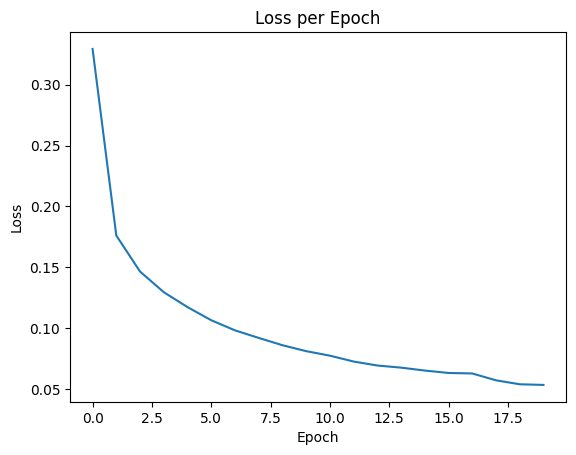

In [22]:
plt.figure()
plt.plot(epoch_losses_history)
plt.title("Loss per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

We can do the same as the Loss with the Accuracy.

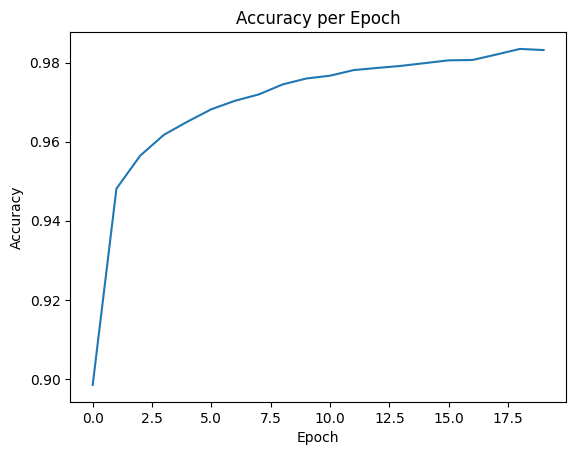

In [23]:
plt.figure()
plt.plot(epoch_accuracies_history)
plt.title("Accuracy per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()

Finally we can run the neural network with images that it never has seen to test how good it is to generalize.\
So we call the function of Foward_Pass with the trained weights and comparate it's predictions with the correct labels.

In [24]:
_,_,_,A2 = Foward_Pass(inputs_test,W1,B1,W2,B2)
preds = np.argmax(A2, axis=1)
correct_ans = np.sum(preds == targets_test)
accuracy_with_test_data = correct_ans / targets_test.size
print(accuracy_with_test_data)

0.9585


In this last demostration I gonna show the image and the prediction.

In [25]:
nm_imgs = 10
indexes = np.random.choice(inputs_test.shape[0],nm_imgs, replace=False)

_,_,_,A2 = Foward_Pass(inputs_test[indexes],W1,B1,W2,B2)
preds_subset = np.argmax(A2, axis=1)
true_subset = targets_test[indexes]

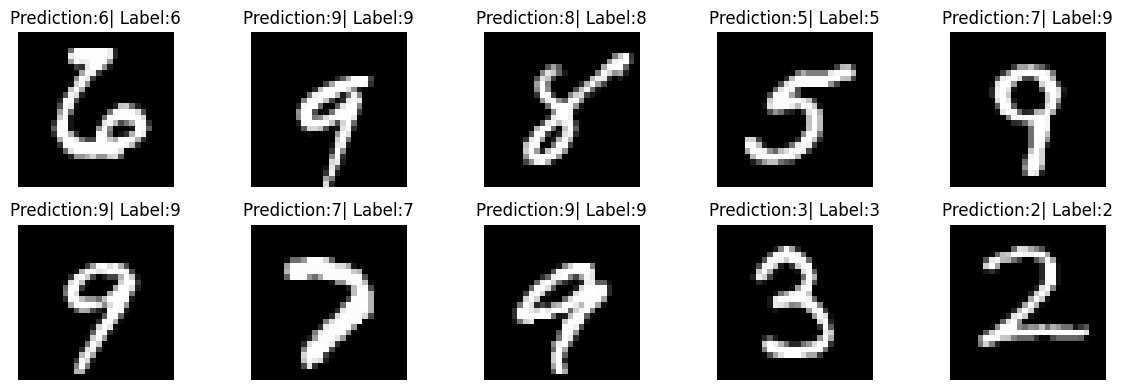

In [28]:
plt.figure(figsize=(12,4))

for i in range(nm_imgs):
    plt.subplot(2,5,i+1)
    plt.imshow(inputs_test[indexes][i].reshape(28,28),cmap="gray")
    plt.title(f"Prediction:{preds_subset[i]}| Label:{true_subset[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

This is How many errors did I have testing the model with the Test Data.

In [31]:
wrong_idxs = np.where(preds != targets_test)[0]
print(f"Total errors:{wrong_idxs.size}")

Total errors:415


And Here are the errors and how they look like.

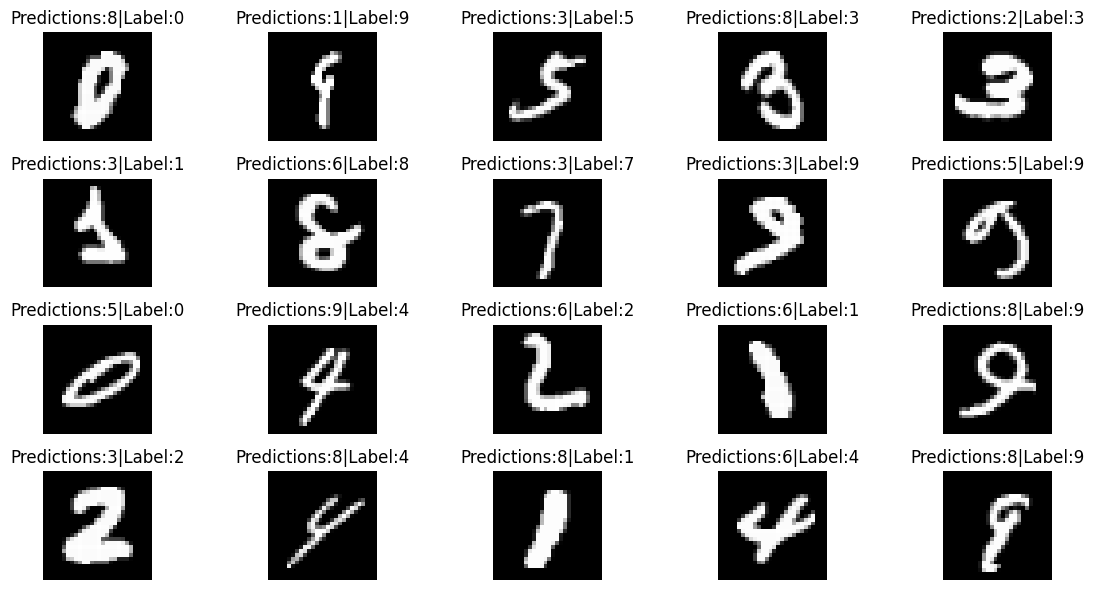

In [32]:
num_images = 20
num_imgs = min(num_images,wrong_idxs.size)

chosen = np.random.choice(wrong_idxs,num_imgs,replace=False)

plt.figure(figsize=(12,6))

for i,idx in enumerate(chosen):
    plt.subplot(4,5,i+1)
    plt.imshow(inputs_test[idx].reshape(28,28),cmap="gray")
    plt.title(f"Predictions:{preds[idx]}|Label:{targets_test[idx]}")
    plt.axis("off")

plt.tight_layout()
plt.show()